In [1]:
import sys; sys.path.insert(0, '../../');
from methods.config import *
import methods.util as util
import numpy as np; rnd = np.random.default_rng()
import matplotlib.pyplot as plt
import methods.fastq_util as fq
import pickle
import os
import scipy.stats

import methods.shared as shared
from importlib import reload
reload(shared)

<module 'methods.shared' from '/Users/daniel/Documents/GoodLab/kim_barcodes/scripts/fig0_data_processing/../../methods/shared.py'>

('E1', 4, 9)
('E1', 6, 29)
('E2', 15, 16)
('E2', 3, 15)
('E2', 3, 2)
('E2', 7, 6)
('E1', 2, 22)
('E2', 8, 8)
('E2', 10, 7)
('E2', 4, 6)
('E2', 11, 25)
('E1', 6, 54)
('E2', 13, 43)
('E2', 9, 21)
('E1', 4, 16)
('E2', 3, 18)
('E1', 12, 5)
('E1', 9, 2)
('E1', 8, 36)
('E1', 7, 18)
('E1', 5, 22)
('E1', 5, 14)
('E2', 'S2_delay', 0)
('E1', 1, 9)
('E2', 8, 18)
('E1', 4, 27)
('E1', 8, 20)
('E1', 6, 7)
('E1', 6, 9)
('E1', 12, 27)
('E2', 7, 4)
('E1', 3, 17)
('E1', 6, 2)
('E2', 6, 4)
('E2', 9, 35)
('E2', 1, 21)
('E1', 3, 6)
('E1', 3, 22)
('E2', 2, 43)
('E2', 13, 55)
('E1', 4, 29)
('E2', 2, 50)
('E2', 10, 5)
('E2', 4, 43)
('E1', 6, 5)
('E2', 12, 25)
('E2', 8, 28)
('E2', 'S5', 0)
('E1', 5, 54)
('E1', 7, 16)
('E1', 2, 4)
('E2', 7, 8)
('E2', 6, 55)
('E2', 10, 6)
('E1', 3, 12)
('E1', 4, 22)
('E1', 3, 3)
('E1', 1, 7)
('E1', 11, 33)
('E1', 6, 12)
('E1', 12, 15)
('E1', 8, 47)
('E1', 10, 2)
('E2', 8, 6)
('E1', 7, 7)
('E1', 5, 40)
('E1', 3, 29)
('E1', 4, 18)
('E2', 12, 43)
('E1', 8, 9)
('E2', 13, 21)
('E2', 

(array([ 82., 179.,  97.,  25.,  36.,  14.,   8.,   5.,   5.,   3.]),
 array([ 4.19135448,  6.63639536,  9.08143624, 11.52647712, 13.97151799,
        16.41655887, 18.86159975, 21.30664063, 23.75168151, 26.19672239,
        28.64176327]),
 <BarContainer object of 10 artists>)

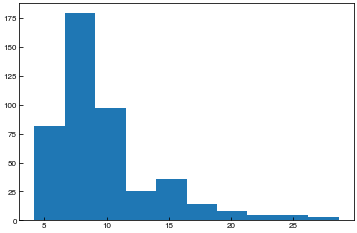

In [2]:
with open(f'{pickled_dir}/pickled_noise_inference.pkl', 'rb') as f:
    barseq_noise_inferences = pickle.load(f)

col_mouse_map = {index:lib_id for lib_id, index in shared.vivo_row_ids.items()}
col_vitro_map = {index:lib_id for lib_id, index in shared.well_col_map.items()}

x = []
y = []
frac_low_diversity = []
for (expt, mouse, day), noise_dict in list(barseq_noise_inferences.items()):
    if expt not in ['E1', 'E2']: #vivo libraries first
        continue

    print((expt, mouse, day))

    nominal_depth = int(noise_dict['Nominal Depth'])
    p, Z1, Z2, D1, D2 = [float(noise_dict[k]) for k in ['p', 'Z1', 'Z2', 'D1', 'D2']]
    
    if Z2 > Z1: # if somehow these were switched during inference, make Z1 the larger one
        Z1, Z2 = Z2, Z1
        D1, D2 = D2, D1
        p = 1-p

    freq_array = shared.freq_array[shared.vivo_row_ids[(expt, mouse, day)]]
    y.append(Z2 * D2)

    frac_low_diversity.append( Z2*D2 / (Z1*D1 + Z2*D2) )

    if Z2 * D2 > 3*Z1 * D1:
        D_det = nominal_depth
    else:
        D_det = D1 * (1-np.exp(-(Z1+Z2*D2/D1))) 


    bincount = [int(e) for e in noise_dict['n. barcode-rUMI reads (<1%)'].split(',')]
    cutoff = 10
    large_bincount = bincount[cutoff:]
    mean = np.sum(large_bincount*np.arange(cutoff, len(large_bincount)+cutoff)) / np.sum(large_bincount)
    var = np.sum(large_bincount*np.arange(cutoff, len(large_bincount)+cutoff)**2) / np.sum(large_bincount) - mean**2

    expected_var = Z1 

    excess_var = var/expected_var

    x.append((Z1*D1+Z2*D2)/D1 / excess_var)

fig, ax = plt.subplots()
ax.hist(x)


E2 5 50


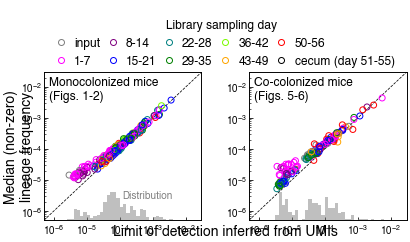

In [3]:
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10

fig = plt.figure(figsize=(6.5,4))
gs = plt.GridSpec(2, 2, height_ratios=(1,3), width_ratios=[1,1], wspace=0.3, figure=fig)
outer_ax = fig.add_subplot(gs[1, :])
util.turn_off_ax(outer_ax)
outer_ax.set_xlabel('Limit of detection inferred from UMIs', fontsize=14)
outer_ax.set_ylabel('Median (non-zero)\nlineage frequency', fontsize=14, labelpad=10)


cmap = {day+7*week: color for day in range(1,8) for week, color in enumerate(['fuchsia', 'purple', 'blue', 'teal', 'green', 'lawngreen', 'orange', 'red'])}
cmap['cecum'] = 'black'
cmap[0] = 'grey'
legend_markers = [plt.Line2D([0], [0], marker='o', linestyle='none', mec=color, mfc='none') \
                  for week, color in enumerate(['grey', 'fuchsia', 'purple', 'blue', 'teal', 'green', 'lawngreen', 'orange', 'red', 'black'])]
legend_ax = fig.add_subplot(gs[0, :])
util.turn_off_ax(legend_ax)
legend_ax.legend(legend_markers, ['input']+[f'{1+7*week}-{7*(week+1)}' for week in range(0,8)] + ['cecum (day 51-55)'], title='Library sampling day', title_fontsize=12,
                  loc=(0.0, -0.4), ncol=5, fontsize=12, frameon=False, columnspacing=0.05, handletextpad=0.1)


E1_ax = fig.add_subplot(gs[1, 0])
E2_ax = fig.add_subplot(gs[1,1])

E1_ax.text(0.03, 0.97, 'Monocolonized mice\n(Figs. 1-2)', transform=E1_ax.transAxes, va='top', fontsize=12)
E2_ax.text(0.03, 0.97, 'Co-colonized mice\n(Figs. 5-6)', transform=E2_ax.transAxes, va='top', fontsize=12)

P1_index, P2_index = 0, 1
P1_freqs = shared.freq_array[P1_index]
P2_freqs = shared.freq_array[P2_index]
median_P1 = np.median(P1_freqs[P1_freqs > 0])
median_P2 = np.median(P2_freqs[P2_freqs > 0])

x, y = [], []
w, z = [], []

lib_Deff = {}
vivo_Deff_array = np.full(shared.read_array.shape[0], 0)

frac_low_diversity = []
for (expt, mouse, day), noise_dict in list(barseq_noise_inferences.items()):
    if expt not in ['E1', 'E2']: #vivo libraries first
        continue

    nominal_depth = int(noise_dict['Nominal Depth'])
    p, Z1, Z2, D1, D2 = [float(noise_dict[k]) for k in ['p', 'Z1', 'Z2', 'D1', 'D2']]
    
    if Z2 > Z1: # if somehow these were switched during inference, make Z1 the larger one
        Z1, Z2 = Z2, Z1
        D1, D2 = D2, D1
        p = 1-p

    freq_array = shared.freq_array[shared.vivo_row_ids[(expt, mouse, day)]]
    y.append(Z2 * D2)

    frac_low_diversity.append( Z2*D2 / (Z1*D1 + Z2*D2) )

    if Z2 * D2 > 3*Z1 * D1:
        D_det = nominal_depth
    else:
        D_det = D1 * (1-np.exp(-(Z1+Z2*D2/D1))) 

    median_nonzero_freq_in_lib = np.median(freq_array[freq_array > 0])

    if expt == 'E1':
        E1_ax.scatter(1/D_det, median_nonzero_freq_in_lib, marker='o', facecolors='none', edgecolors=cmap[day])
        x.append(1/D_det)

    if expt == 'E2' and mouse not in [5, 10, 15]: #exclude low-diversity mice for clarity
        E2_ax.scatter(1/D_det, median_nonzero_freq_in_lib, marker='o', facecolors='none', edgecolors=cmap[day] )
        y.append(1/D_det)

    if median_nonzero_freq_in_lib < 0.01 * 1/D_det:
        print(expt, mouse, day)

    lib_Deff[(expt, mouse, day)] = D_det
    index = shared.vivo_row_ids[(expt, mouse, day)]
    vivo_Deff_array[index] = D_det

with open(f'{pickled_dir}/vivo_Deff.pkl', 'wb') as f:
    pickle.dump([vivo_Deff_array, lib_Deff], f)

E1_ax_dist = E1_ax.twinx()
E1_ax_dist.hist(x, bins=np.logspace(-6, -2, 41), color='grey', alpha=0.5, density=False, histtype='stepfilled', lw=0)
E2_ax_dist = E2_ax.twinx()
E2_ax_dist.hist(y, bins=np.logspace(-6, -2, 41), color='grey', alpha=0.5, density=False, histtype='stepfilled', lw=0)
for dist_ax in [E1_ax_dist, E2_ax_dist]:
    dist_ax.set_yticks([])
    dist_ax.set_ylim(dist_ax.get_ylim()[0], dist_ax.get_ylim()[1]*5)
E1_ax_dist.text(0.5, 0.15, "Distribution", transform=E1_ax_dist.transAxes, ha='left', color='grey', fontsize=10)

for i, ax in enumerate([E1_ax, E2_ax]):
    util.plot_diagonal(ax)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(0.5*10**-6, 3*10**-2)
    ax.set_ylim(0.5*10**-6, 3*10**-2)
    ax.set_xticks([10**-6, 10**-5, 10**-4, 10**-3, 10**-2])

# E1_ax.axhspan(median_P1, median_P2, color='grey', alpha=0.4, lw=0)
# E2_day0_freqs = shared.freq_array[2:6]
# E2_day0_median = [np.median(day0_freqs[day0_freqs > 0]) for day0_freqs in E2_day0_freqs]
# E2_ax.axhspan(np.min(E2_day0_median), np.max(E2_day0_median), color='grey', alpha=0.4, lw=0)

# fig.savefig(f'{plot_dir}/sfig_umi_dereplication.pdf')
# plt.rcParams['svg.fonttype'] = 'none'
# fig.savefig(f'{dropbox_dir}/SI_Figures/umi_dereplication/sfig_umi_dereplication.svg', format='svg', transparent=True, bbox_inches='tight')
# fig.savefig(f'{dropbox_dir}/SI_Figures/umi_dereplication/sfig_umi_dereplication.pdf', transparent=True, bbox_inches='tight')


vitro p2_A9 5 ('precticx', 'V1')
Weak jackpot p2_E6 31
vitro p1_B2 15 ('stachyose', 'V5')
Weak jackpot p1_F1 31
Weak jackpot p1_B7 31
vitro p2_E6 5 ('cravingzgone', 'V2')
Weak jackpot p2_D9 31
Weak jackpot p2_A3 31
Weak jackpot p1_F1 15
Weak jackpot p2_A3 5
Weak jackpot p2_B1 31
vitro p2_C9 5 ('precticx', 'V1')
Weak jackpot p1_B2 31
vitro p2_B9 5 ('precticx', 'V4')
Weak jackpot p1_C2 31
Weak jackpot p2_G6 31
Weak jackpot p2_A2 31
Weak jackpot p2_F6 5
Weak jackpot p1_G1 31
Weak jackpot p2_B9 31
vitro p2_G9 5 ('sunfiber', 'V1')
vitro p2_E9 31 ('sunfiber', 'V1')
Weak jackpot p1_G1 5
Weak jackpot p2_E2 31
Weak jackpot p1_G1 15
Weak jackpot p1_A2 31
Weak jackpot p2_D3 31
Weak jackpot p1_A2 5
Weak jackpot p2_C3 31
vitro p2_F9 5 ('sunfiber', 'V4')
Weak jackpot p1_H2 31
vitro p2_H9 5 ('sunfiber', 'V4')
Weak jackpot p2_D2 31
vitro p2_D9 5 ('precticx', 'V4')
Weak jackpot p2_C1 31
vitro p2_F9 31 ('sunfiber', 'V4')
Weak jackpot p2_F6 31
Weak jackpot p2_H6 31
vitro p2_H6 5 ('cravingzgone', 'V5')
vi

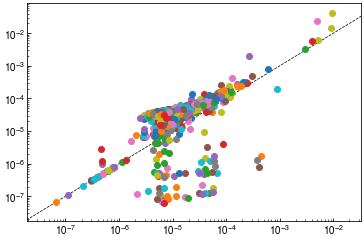

In [7]:
## do same for vitro arrays
with open(f'{pickled_dir}/vitro_array.pkl', 'rb') as f:
    vitro_read_array = pickle.load(f)
vitro_freq_array = np.einsum('ij, i->ij', vitro_read_array, vitro_read_array.sum(axis=1)**-1.)

lib_vitro_Deff = {}
vitro_Deff_array = np.full(vitro_freq_array.shape[0], 0)

fig, ax = plt.subplots()

for (expt, well, passage), noise_dict in list(barseq_noise_inferences.items()):
    if expt != 'vitro': #now vitro
        continue


    nominal_depth = int(noise_dict['Nominal Depth'])
    p, Z1, Z2, D1, D2 = [float(noise_dict[k]) for k in ['p', 'Z1', 'Z2', 'D1', 'D2']]
    
    if Z2 > Z1: # if somehow these were switched during inference, make Z1 the larger one
        Z1, Z2 = Z2, Z1
        D1, D2 = D2, D1
        p = 1-p

    freq_array = vitro_freq_array[shared.well_col_map[(expt, well, passage)]]

    y.append(Z2 * D2)

    if Z2 * D2 > 3*Z1 * D1:
        print('Weak jackpot', well, passage)
        D_det = nominal_depth
    else:
        # D_det = D1 * (1-np.exp(-Z1))
        D_det = D1 * (1-np.exp(-(Z1+Z2*D2/D1))) 

    lib_vitro_Deff[(expt, well, passage)] = D_det
    index = shared.well_col_map[(expt, well, passage)]
    vitro_Deff_array[index] = D_det

    ### plotting
    median_nonzero_freq_in_lib = np.median(freq_array[ (freq_array > 0)])
    ax.scatter( 1/D_det, median_nonzero_freq_in_lib )

    if well[0] == 'V':
        continue
    medium = shared.well_to_medium_map[well]

    if median_nonzero_freq_in_lib  < 1/100 * 1/D_det:
        print(expt, well, passage, medium)



with open(f'{pickled_dir}/vitro_Deff.pkl', 'wb') as f:
    pickle.dump([vitro_Deff_array, lib_vitro_Deff], f)

ax.set_xscale('log')
ax.set_yscale('log')
util.plot_diagonal(ax)


6283
8841
10760


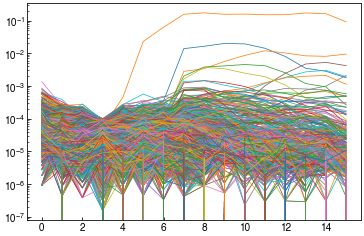

In [114]:
mouse = 7
freqs = shared.freq_array[shared.vivo_row_ids[('E2', 7, 3)]] + 1e-8
s1_indices = shared.barcode_pool_assignments['set2'][0] 
s1_freqs = freqs[s1_indices]

f1 = shared.freq_array[shared.vivo_row_ids[('E2', 7, 3)]] 
f2 = shared.freq_array[shared.vivo_row_ids[('E2', 7, 4)]] 
f3 = shared.freq_array[shared.vivo_row_ids[('E2', 7, 5)]] 
mice_freqs = shared.freq_array[shared.mouse_meta['E2'][7][1]]

z= ((f1>0)&(f2>0)&(f3>0)& (f3 < 10**-4))
print(z.sum())
print( ((f1>0)&(f2>0)&(f3>0)).sum() )


fig, ax = plt.subplots()
ax.plot(mice_freqs[:, z])
ax.set_yscale('log')

print( (s1_freqs > 10**-7).sum() )

# fig, ax = plt.subplots()
# ax.hist(s1_freqs[s1_freqs>0], bins=np.logspace(-8, 0, 81))
# ax.set_xscale('log')

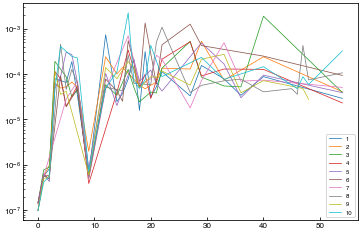

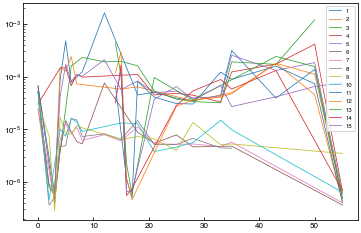

In [102]:
for expt, mice in (['E1', range(1, 11)], ['E2', range(1, 16)]):
    fig, ax = plt.subplots()
    for mouse in mice:
        days, rows, cec = shared.mouse_meta[expt][mouse]

        freqs = shared.freq_array[rows]
        Deffs = shared.Deff_array[rows]

        ax.plot( days, Deffs**-1., label=mouse)
        ax.set_yscale('log')
        ax.legend()

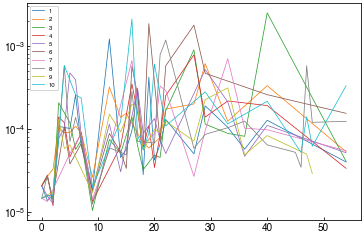

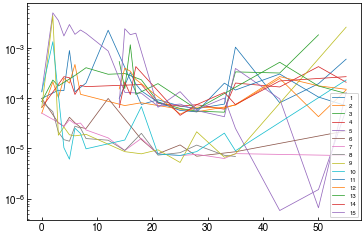

In [153]:
for expt, mice in (['E1', range(1, 11)], ['E2', range(1, 16)]):
    fig, ax = plt.subplots()
    for mouse in mice:
        days, rows, cec = shared.mouse_meta[expt][mouse]

        freqs = shared.freq_array[rows]
        med_freq = [np.median(f[f>0])  for f in freqs]

        Deffs = shared.Deff_array[rows]

        ax.plot( days, med_freq, label=mouse)
        ax.set_yscale('log')
        ax.legend()